## Instalacion de dependencias:

In [5]:
!pip install pymupdf langchain langchain-text-splitters pandas matplotlib -q
!pip install -U langchain-text-splitters


## Importaciones:

In [7]:
import fitz  # PyMuPDF
import re
import pandas as pd
import matplotlib.pyplot as plt
from langchain_text_splitters import RecursiveCharacterTextSplitter
from google.colab import files

## Subida de PDF:

In [9]:
subida = files.upload()
pdf_path = list(subida.keys())[0]
print(f'Archivo cargado')

Saving RGUNALM_2023.pdf to RGUNALM_2023 (1).pdf
Archivo cargado


## Extracción de texto:

Se aplica limpieza básica:
- Eliminación de saltos de línea excesivos (más de 3 consecutivos)
- Reducción de espacios múltiples a uno solo
- Descarte de páginas con menos de 50 caracteres (portadas o páginas vacías)

In [10]:
def extraer_texto_pdf(ruta_pdf):
    doc = fitz.open(ruta_pdf)
    paginas = []

    for num_pagina in range(len(doc)):
        pagina = doc[num_pagina]
        texto = pagina.get_text("text")
        texto = texto.strip()
        texto = re.sub(r'\n{3,}', '\n\n', texto)
        texto = re.sub(r'[ \t]+', ' ', texto)

        if len(texto) > 50:
            paginas.append({
                'pagina': num_pagina + 1,
                'texto': texto,
                'num_caracteres': len(texto),
                'fuente': ruta_pdf
            })

    doc.close()
    return paginas

In [11]:
paginas = extraer_texto_pdf(pdf_path)
print(f'Total de páginas extraídas:  {len(paginas)}')
print(f'Total de caracteres:         {sum(p["num_caracteres"] for p in paginas):,}')
print(f'\n--- Muestra: Página 1 ---')
print(paginas[0]['texto'][:500])

Total de páginas extraídas:  191
Total de caracteres:         369,895

--- Muestra: Página 1 ---
REGLAMENTO GENERAL 
 
 
 
 
 
2017 
 
UNIVERSIDAD NACIONAL AGRARIA 
LA MOLINA


## Exploracion del documento:

=== Estadísticas del documento ===
count     191.0
mean     1937.0
std       325.0
min        77.0
25%      1800.0
50%      1931.0
75%      2056.0
max      3774.0
Name: num_caracteres, dtype: float64


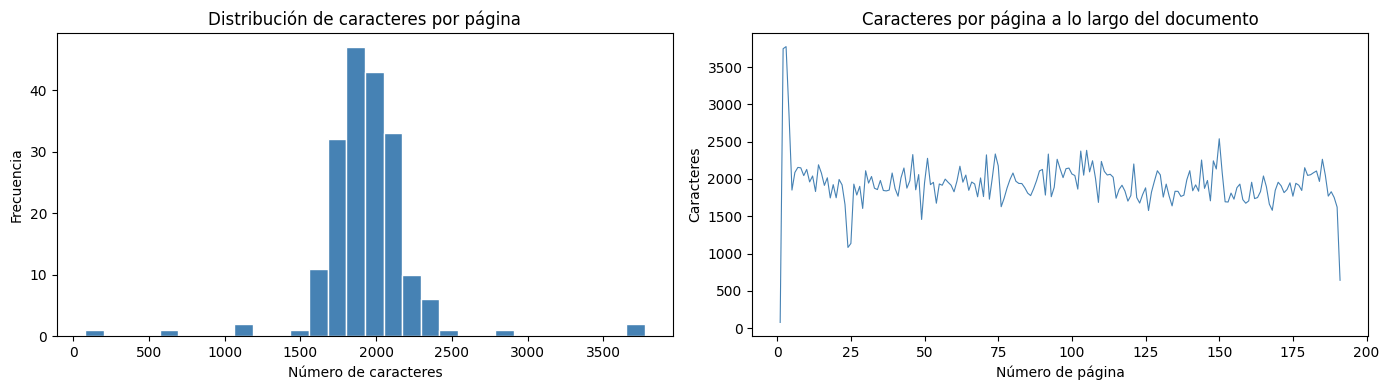

In [12]:
df_paginas = pd.DataFrame(paginas)

print('=== Estadísticas del documento ===')
print(df_paginas['num_caracteres'].describe().round(0))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma de caracteres por página
axes[0].hist(df_paginas['num_caracteres'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de caracteres por página')
axes[0].set_xlabel('Número de caracteres')
axes[0].set_ylabel('Frecuencia')

# Caracteres por página (línea)
axes[1].plot(df_paginas['pagina'], df_paginas['num_caracteres'], color='steelblue', linewidth=0.8)
axes[1].set_title('Caracteres por página a lo largo del documento')
axes[1].set_xlabel('Número de página')
axes[1].set_ylabel('Caracteres')

plt.tight_layout()
plt.show()

## Construccion de texto completo:

In [13]:
texto_completo = '\n\n'.join([p['texto'] for p in paginas])
print(f'Longitud total del texto: {len(texto_completo):,} caracteres')

Longitud total del texto: 370,275 caracteres


## Chunking:

Se implementa **RecursiveCharacterTextSplitter** con dos configuraciones para comparar:


| Parámetro | Valor | Justificación |
|-----------|-------|---------------|
| `chunk_size` | 700 | Captura 1–2 artículos completos sin cortar ideas a la mitad |
| `chunk_overlap` | 100 | Evita perder contexto en el límite entre chunks (≈14% del chunk) |
| Separadores | `\n\n`, `\n`, `.`, ` ` | Respeta la estructura de párrafos y artículos del reglamento |


In [14]:
#Configuracion princial (sera utilizada a lo largo del proyecto)
CHUNK_SIZE    = 700
CHUNK_OVERLAP = 100

splitter_principal = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separators=['\n\n', '\n', '.', ' ', ''],
    length_function=len
)

#Configuracion alternativa (unicamente con propositos de comparacion)
splitter_alternativo = RecursiveCharacterTextSplitter(
    chunk_size=400,
    chunk_overlap=50,
    separators=['\n\n', '\n', '.', ' ', ''],
    length_function=len
)

chunks_principal   = splitter_principal.create_documents([texto_completo])
chunks_alternativo = splitter_alternativo.create_documents([texto_completo])

print('=== Comparación de configuraciones de chunking ===')
print(f'Config A (700/100): {len(chunks_principal):>5} chunks')
print(f'Config B (400/50):  {len(chunks_alternativo):>5} chunks')

=== Comparación de configuraciones de chunking ===
Config A (700/100):   695 chunks
Config B (400/50):   1121 chunks


## Analisis de los chunks:

Se comparan ambas configuraciones en:
- Número total de chunks generados
- Tamaño promedio, mínimo y máximo de cada chunk
- Distribución visual mediante histogramas

Configuración  N° chunks  Media (chars)  Mín (chars)  Máx (chars)
  A (700/100)        695            584           77          698
   B (400/50)       1121            333           16          399


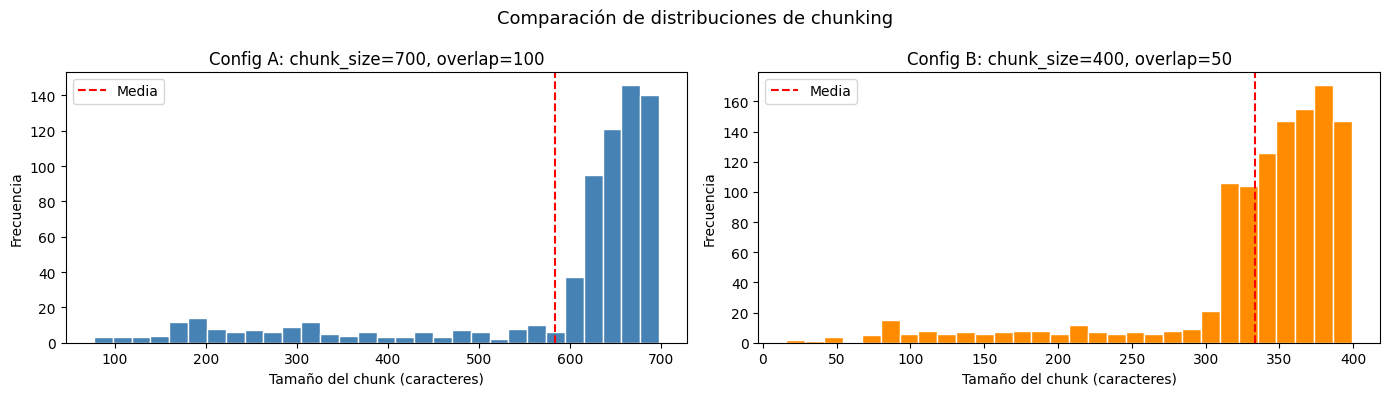

In [15]:
longitudes_a = [len(c.page_content) for c in chunks_principal]
longitudes_b = [len(c.page_content) for c in chunks_alternativo]

df_comp = pd.DataFrame({
    'Configuración': ['A (700/100)', 'B (400/50)'],
    'N° chunks':     [len(longitudes_a), len(longitudes_b)],
    'Media (chars)': [round(sum(longitudes_a)/len(longitudes_a)), round(sum(longitudes_b)/len(longitudes_b))],
    'Mín (chars)':   [min(longitudes_a), min(longitudes_b)],
    'Máx (chars)':   [max(longitudes_a), max(longitudes_b)]
})
print(df_comp.to_string(index=False))

# Histograma comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(longitudes_a, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Config A: chunk_size=700, overlap=100')
axes[0].set_xlabel('Tamaño del chunk (caracteres)')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(sum(longitudes_a)/len(longitudes_a), color='red', linestyle='--', label='Media')
axes[0].legend()

axes[1].hist(longitudes_b, bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('Config B: chunk_size=400, overlap=50')
axes[1].set_xlabel('Tamaño del chunk (caracteres)')
axes[1].set_ylabel('Frecuencia')
axes[1].axvline(sum(longitudes_b)/len(longitudes_b), color='red', linestyle='--', label='Media')
axes[1].legend()

plt.suptitle('Comparación de distribuciones de chunking', fontsize=13)
plt.tight_layout()
plt.show()

## Inspeccion de chunks de muestra:

Se muestran los chunks #1 y #50 para verificar que el corte
es coherente y no parte artículos del reglamento a la mitad.

In [16]:
print('=== CHUNK #1 (Config A) ===')
print(chunks_principal[0].page_content)
print(f'\nLongitud: {len(chunks_principal[0].page_content)} caracteres')

print('\n' + '='*60)
print('=== CHUNK #50 (Config A) ===')
print(chunks_principal[50].page_content)
print(f'\nLongitud: {len(chunks_principal[50].page_content)} caracteres')

=== CHUNK #1 (Config A) ===
REGLAMENTO GENERAL 
 
 
 
 
 
2017 
 
UNIVERSIDAD NACIONAL AGRARIA 
LA MOLINA

Longitud: 77 caracteres

=== CHUNK #50 (Config A) ===
REGLAMENTO GENERAL – Res. No. 0001-2017-AU-UNALM 
2017 
 
 
 
12 
programas de investigación, círculos y centros de investigación, nombrados por el 
consejo de facultad. 
 
b) la unidad de investigación de cada facultad contará con el apoyo de un profesional 
especializado, asignado por el vicerrectorado de investigación; el cual estará bajo la 
supervisión del director de investigación. 
 
ARTÍCULO 23°.- Son funciones del director de la unidad de investigación: 
a) coordinar sus acciones con el vicerrectorado de investigación; 
b) fomentar y apoyar la elaboración de proyectos de investigación (como mecanismo 
para conseguir fondos nacionales e internacionales);

Longitud: 670 caracteres


## Agregando metadatos a cada chunk:

- **fuente:** nombre del archivo PDF original
- **tipo:** tipo de documento (reglamento_universitario)
- **chunk_id:** índice del chunk
- **total_chunks:** total de chunks generados

In [17]:
def agregar_metadatos(chunks, fuente, tipo_doc='reglamento'):
    for i, chunk in enumerate(chunks):
        chunk.metadata.update({
            'fuente':    fuente,
            'tipo':      tipo_doc,
            'chunk_id':  i,
            'total_chunks': len(chunks)
        })
    return chunks


chunks_final = agregar_metadatos(
    chunks_principal,
    fuente=pdf_path,
    tipo_doc='reglamento_universitario'
)

# Verificar metadatos
print('Metadatos del chunk #0:')
print(chunks_final[0].metadata)
print(f'\nTotal de chunks listos para embedding: {len(chunks_final)}')

Metadatos del chunk #0:
{'fuente': 'RGUNALM_2023 (1).pdf', 'tipo': 'reglamento_universitario', 'chunk_id': 0, 'total_chunks': 695}

Total de chunks listos para embedding: 695


## Guardado de chunks procesados:

In [18]:
import json

df_chunks = pd.DataFrame([
    {
        'chunk_id':   c.metadata['chunk_id'],
        'texto':      c.page_content,
        'longitud':   len(c.page_content),
        'fuente':     c.metadata['fuente'],
        'tipo':       c.metadata['tipo']
    }
    for c in chunks_final
])

df_chunks.to_csv('chunks_reglamento.csv', index=False, encoding='utf-8')
print(f'Guardado: chunks_reglamento.csv ({len(df_chunks)} filas)')
print(df_chunks.head(3))

Guardado: chunks_reglamento.csv (695 filas)
   chunk_id                                              texto  longitud  \
0         0  REGLAMENTO GENERAL \n \n \n \n \n \n2017 \n \n...        77   
1         1  REGLAMENTO GENERAL – Res. No. 0001-2017-AU-UNA...       589   
2         2  2.2 DE LAS FACULTADES ...........................       644   

                 fuente                      tipo  
0  RGUNALM_2023 (1).pdf  reglamento_universitario  
1  RGUNALM_2023 (1).pdf  reglamento_universitario  
2  RGUNALM_2023 (1).pdf  reglamento_universitario  
